## KELT-20b Evolution and Parameter Sweep

### Known Parameters

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
np.random.seed(42)

# Stellar parameters - KELT-20
stellar_mass = 1.76  # solar masses
stellar_radius = 1.565 * 0.00465  # AU (1.6 solar radii)
k2_s = 0.0045 # Love number

# Planetary parameters - KELT-20b
planetary_mass = 1 * 0.000954588  # solar masses (1 Jupiter mass)
planetary_radius = 1.741 * 0.00465  # AU (1.741 Jupiter radii) 
k2_p = 0.5  # 0.5-0.3 

G = 4*np.pi**2  # AU^3 / yr^2 Msun

# Initial spin
period = 0.8  # days
period = period * 0.00273973  # years
omega_0 = 2 * np.pi / period

# Final conditions
a_final = 0.0542
e_final = 0
star_age = 1.1e8

The snow line of a bright star scales as r=2.7 * sqrt(Lstar/Lsun). Another relation is r=2.7 *(Mstar/Msun)**2. We find a snow line of 8-9.6 AU, which is much further out than that of the sun. We should explore initial a values beyond the snow line.

In [ ]:
# Snowline
rsnow=2.7 *np.sqrt(12.7)
print(rsnow)
rsnow=2.7 *(1.76)**2
print(rsnow)

### Calculated Parameters

In [14]:
# Initial orbital geometry
a_array = np.linspace(7, 20, 20)
e_array = 1 - 0.025 / a_array

# Convective friction time
m_cgs = 1.76 * 2e33  # stellar mass in grams
r_cgs = 1.565 * 7e10  # stellar radius in cm 
l_cgs = 12.7 * 4e33  # stellar luminosity in erg/s

t_f_s = (m_cgs * r_cgs **2 / l_cgs)**(1/3)  # seconds
t_f = t_f_s / 31556952  # years

# Tidal time lag
tau = 2 * stellar_radius**3 / (G * stellar_mass * t_f)
# tau = tau * 7 ??

# 10% error
tau_10 = 0.1*tau
tau_10

tau_lower = tau - tau_10
tau_upper = tau + tau_10

# # Error propagation
# tau_lower = tau - dtau_converted
# tau_upper = tau + dtau_converted

tau_array = np.linspace(tau_lower, tau_upper, 20)

### Error Propagation

In [ ]:
# Errors
avg_dm = (0.14 + 0.19)/2  # [solar masses]
dm_cgs = avg_dm * 2e33  # [g]

avg_dr = (0.057 + 0.064)/2  # [solar radii]
dr_cgs = avg_dr * 7e10  # [cm]

avg_dl = (2.2 + 1.9)/2  # [solar luminosity]
dl_cgs = avg_dl * 4e33  # [erg/s]

G_cgs = 6.674e-8  # [dyn cm^2 / g^2]

# Checking cgs tau calculation
tau_cgs = 2 * r_cgs**3 / (G_cgs * m_cgs * (m_cgs * r_cgs **2 / l_cgs)**(1/3))
tau_converted = tau_cgs / 31556952

# tau_cgs = 2 * r_cgs**(7/3) * l_cgs**(1/3) / (G_cgs * m_cgs**(4/3))
# tau_converted = tau_cgs / 31556952

# Propagating errors
dtau_tau = np.sqrt((7/3 * dr_cgs/r_cgs)**2 + 
                               (1/3 * dl_cgs/l_cgs)**2 + 
                               (4/3 * dm_cgs/m_cgs)**2)

dtau_converted = dtau_tau * tau_cgs * 2/G_cgs  / 31556952

### Hut Model

In [18]:
def f1_hut(e2):
    return 1 + (31/2)*e2 + (255/8)*e2**2 + (185/16)*e2**3 + (25/64)*e2**4

def f2_hut(e2):
    return 1 + (15/2)*e2 + (45/8)*e2**2 + (5/16)*e2**3

def f3_hut(e2):
    return 1 + (15/4)*e2 + (15/8)*e2**2 + (5/64)*e2**3

def f4_hut(e2):
    return 1 + (3/2)*e2 + (1/8)*e2**2

def f5_hut(e2):
    return 1 + 3*e2 + (3/8)*e2**2


def hut_model(params, t, mstar, rstar, k2star, mplanet, tau):
    a, e, omega = params
    
    global done
    global t_circ
    if e < 1e-3:
        if t_circ == 0:
            t_circ = t
    
    if a < rstar:
        return [0,0,0]
    
    k =  k2star
    
    n = np.sqrt(G*(mstar + mplanet)/a**3)

    T = rstar**3 / (G * mstar *  tau) 

    q = mplanet / mstar

    rg = 0.21  # radius of gyration
    
    da_dt = -6 * (k / T) * q * (1 + q) * (rstar / a)**8 * a * (1 - e**2)**(-15/2) * (
         f1_hut(e**2) - (1 - e**2)**(3/2) * f2_hut(e**2) * omega / n)

    de_dt = -27 * (k / T) * q * (1 + q) * (rstar / a)**8 * e * (1 - e**2)**(-13/2) * (
        f3_hut(e**2) - 11/18 * (1 - e**2)**(3/2) * f4_hut(e**2) * omega / n)

    domega_dt = 3 * (k / T) * (q / rg)**2 * (rstar / a)**6 * n * (1-e**2)**(-6) * (
        f2_hut(e**2) - (1 - e**2)**(3/2) * f5_hut(e**2) * omega / n)

    
    return [da_dt, de_dt, domega_dt]


### Plotting Distance and e vs Time

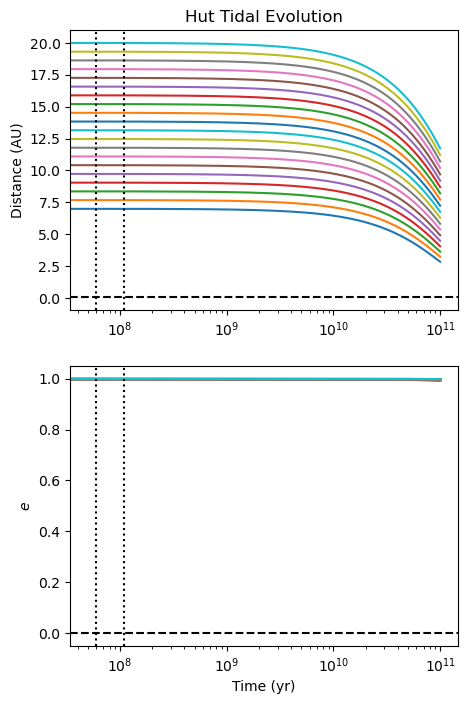

In [26]:
# Time
tmax = 1e11
Nout = 2000
hut_times = np.linspace(0, tmax, Nout)

# Setting up plot
fig, ax = plt.subplots(2, 1, figsize = (5,8))

for i in range(len(a_array)):
    a0 = a_array[i]
    e0 = e_array[i]
    
    initial_cond = [a0, e0, omega_0] 
    
    hut_solution = odeint(hut_model, initial_cond, hut_times, 
                               args = (stellar_mass, stellar_radius, k2_s, 
                                      planetary_mass, tau), mxords = 12)

    
    a_sol = hut_solution[:, 0]
    e_sol = hut_solution[:, 1]
    
    a0 = round(a0, 1)
    e0 = round(e0, 3)
    
    ax[0].plot(hut_times, a_sol, label = f"{a0} AU")
    ax[1].plot(hut_times, e_sol, label = f"{e0}")

ax[0].set_title("Hut Tidal Evolution")
ax[0].set_ylabel("Distance (AU)")
ax[0].set_xscale("log")
ax[0].axhline(y = a_final, color = "k", linestyle = "dashed", label = "target")
ax[0].axvline(x = 60e6, color = "k", linestyle = "dotted", label = "age")
ax[0].axvline(x = 110e6, color = "k", linestyle = "dotted", label = "age")

ax[1].set_ylabel(r'$e$')
ax[1].set_xlabel("Time (yr)")
ax[1].set_xscale("log")
ax[1].axhline(y = 0, color = "k", linestyle = "dashed", label = "target")
ax[1].axvline(x = 60e6, color = "k", linestyle = "dotted", label = "age")
ax[1].axvline(x = 110e6, color = "k", linestyle = "dotted", label = "age")

# ax[0].legend()
# ax[1].legend()

### Preliminary Results (not relevant)

In [ ]:
t_circ_list = []
a_list = []
tau_list = []

# Time
tmax = 1e9
Nout = 2000
hut_times = np.linspace(0, tmax, Nout)

# Setting up plot
# fig, ax = plt.subplots(2, 1, figsize = (5,8))

for i in range(len(tau_array)):
    tau = tau_array[i]
    
    for i in range(len(a_array)):
        a0 = a_array[i]
        e0 = e_array[i]

        done = "no"
        
        a_list.append(a0)
        tau_list.append(tau)
        
        initial_cond = [a0, e0, omega_0] 
        
        hut_solution = odeint(hut_model, initial_cond, hut_times, 
                                   args = (stellar_mass, stellar_radius, k2_s, 
                                          planetary_mass, tau), mxords = 12)
        
        # a_sol = hut_solution[:, 0]
        # e_sol = hut_solution[:, 1]
        
        # a0 = round(a0, 1)
        # e0 = round(e0, 3)
        
#         ax[0].plot(hut_times, a_sol, label = f"{a0} AU")
#         ax[1].plot(hut_times, e_sol, label = f"{e0}")

# ax[0].set_title("Hut Tidal Evolution")
# ax[0].set_ylabel("Distance (AU)")
# ax[0].set_xscale("log")
# ax[0].axhline(y = a_final, color = "k", linestyle = "dashed", label = "target")
# ax[0].axvline(x = star_age, color = "k", linestyle = "dotted", label = "age")
# ax[0].axvline(x = time, color = "k", linestyle = "dashdot", label = "t_circ")

# ax[1].set_ylabel(r'$e$')
# ax[1].set_xlabel("Time (yr)")
# ax[1].set_xscale("log")
# ax[1].axhline(y = 0, color = "k", linestyle = "dashed", label = "target")
# ax[1].axvline(x = star_age, color = "k", linestyle = "dotted", label = "age")
# ax[1].axvline(x = time, color = "k", linestyle = "dashdot", label = "t_circ")


# ax[0].legend()
# ax[1].legend()



### Adding Contour Lines (not relevant)

In [6]:
X, Y = np.meshgrid(a_array, tau_array)

# Time
tmax = 1e9
Nout = 2000
hut_times = np.linspace(0, tmax, Nout)

def t_circ(a, tau):
    e = 1 - 0.025 / a
    
    global t_circ
    t_circ = 0
    
    initial_cond = [a, e, omega_0] 
        
    hut_solution = odeint(hut_model, initial_cond, hut_times, 
                                   args = (stellar_mass, stellar_radius, k2_s, 
                                          planetary_mass, tau), mxords = 12)
    return t_circ

v_t_circ = np.vectorize(t_circ)

xi = v_t_circ(X, Y)


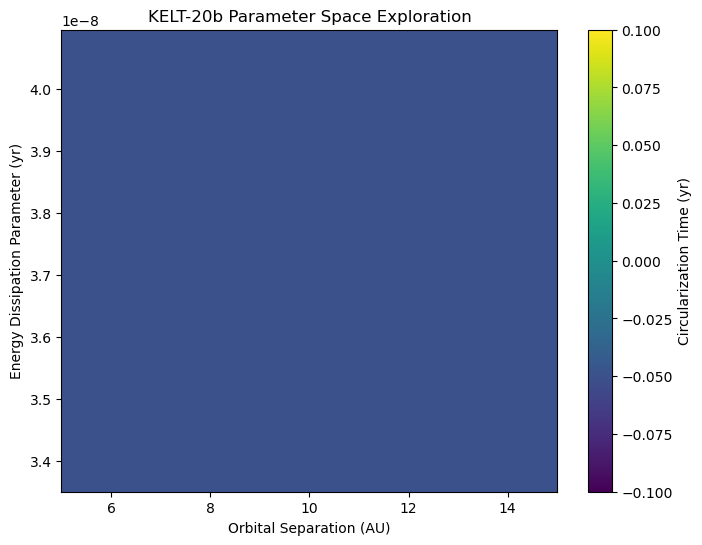

In [7]:
# Creating figure
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, c = xi, s = 80)
plt.xlabel("Orbital Separation (AU)")
plt.ylabel("Energy Dissipation Parameter (yr)")
plt.title("KELT-20b Parameter Space Exploration")
plt.colorbar(label = "Circularization Time (yr)")

# Adding contour lines
levels = [90e6, 110e6, 130e6]
fmt = {90e6: "90 Myr", 110e6:"110 Myr", 130e6: "130 Myr"}

contour = plt.contour(X, Y, xi, levels = levels, colors = "k", linewidths=[1, 2, 1], linestyles = ["--", "-", "--"])
plt.clabel(contour, fmt = fmt, colors='k', fontsize=16)
contourf = plt.contourf(X, Y, xi, levels = 200)
plt.savefig("KELT-20b_figure")